# Everpeak analysis

## Limpieza

In [40]:
#Importar Pandas y cargar datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/datasets/everpeak_retail.csv')
df

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0
...,...,...,...,...,...,...,...,...,...,...,...
5003,5004,NaN,1154,Fashion,368,0,6256,debit_card,Miami,FL,22.0
5004,5005,NaN,1408,Electronics,687,15,10025,credit_card,Houston,TX,80.0
5005,5006,NaN,2935,Toys,797,0,5579,credit_card,Miami,FL,35.0
5006,5007,NaN,2452,Toys,228,0,4332,credit_card,Miami,FL,42.0


In [26]:
# observar valores ausentes iniciales
print("Valores ausentes iniciales:")
df[["customer_age", "price"]].isna().sum()

Valores ausentes iniciales:


customer_age    150
price             0
dtype: int64

In [27]:
def reemplazar_sentinels(df, sentinels, numeric_cols):
    for col in numeric_cols:
        df[col] = df[col].replace(sentinels, pd.NA)
    return df


In [28]:
def rellenar_ausentes(df, cols_fill):
    for col in cols_fill:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].mean(), inplace=True)
    return df

In [29]:
# Crear función pipeline
def limpiar_df(df):
    valores_erroneos = [-999, 999, 0, 1]
    columnas_numericas = ["customer_age", "price"]
    
    df = reemplazar_sentinels(df, valores_erroneos,  columnas_numericas) 
    df = rellenar_ausentes(df, columnas_numericas)
    return df

In [30]:
# Aplicar pipeline completo
df = limpiar_df(df)
print("\nValores ausentes después del pipeline:")
df[["customer_age", "price"]].isna().sum()


Valores ausentes después del pipeline:


customer_age    0
price           0
dtype: int64

In [31]:
#Resumen estadistico categorías Fashion y Sports
# Crear dataframes para cada categoría
df_fashion = df[df["product_category"]=="Fashion"]
df_sports = df[df["product_category"]=="Sports"]

# --- Resumen de columnas numéricas con describe()
columnas_numericas = ['order_value', 'customer_age', 'price', 'quantity']


In [32]:
print('Resumen estadístico de la categoría Fashion')
print(df_fashion[columnas_numericas].describe())

Resumen estadístico de la categoría Fashion
         order_value  customer_age         price    quantity
count     740.000000    740.000000    740.000000  740.000000
mean     8741.775676     48.034392    585.240663   15.164865
std     10312.376778     18.096992    655.100389   30.697218
min       122.000000     18.000000     25.000000    0.000000
25%      2916.000000     32.000000    274.750000    0.000000
50%      8077.500000     47.000000    457.000000    0.000000
75%     12526.500000     64.000000    679.000000   21.000000
max    224884.000000     80.000000  11836.000000  284.000000


In [33]:
print('Resumen estadístico de la categoría Sports')
print(df_sports[columnas_numericas].describe())

Resumen estadístico de la categoría Sports
        order_value  customer_age        price    quantity
count    704.000000    704.000000   704.000000  704.000000
mean   10348.357955     49.689850   840.862216   12.869318
std     8815.365733     17.451683   848.098975   26.434814
min      195.000000     18.000000    47.000000    0.000000
25%     4301.500000     36.000000   347.000000    0.000000
50%    10557.500000     49.122491   555.000000    0.000000
75%    13447.250000     64.250000  1017.000000   17.000000
max    78964.000000     80.000000  9541.000000  260.000000


In [34]:
#Resumen categórico Nueva York y Chicago
#  Columnas categóricas
columnas_categoricas = ['payment_method', 'product_category']

# Filtra por ciudad
df_ny = df[df["city"] == "New York"]
df_chicago = df[df["city"] == "Chicago"]


In [35]:
# Resumen categórico New York
print("Resumen categórico - New York")
print(df_ny[columnas_categoricas].describe())

Resumen categórico - New York
       payment_method product_category
count             497              497
unique              4                8
top       credit_card             Toys
freq              271               76


In [36]:
# Resumen categórico Chicago
print("Resumen categórico - Chicago")
print(df_chicago[columnas_categoricas].describe())

Resumen categórico - Chicago
       payment_method product_category
count             482              482
unique              4                8
top       credit_card             Toys
freq              284               74


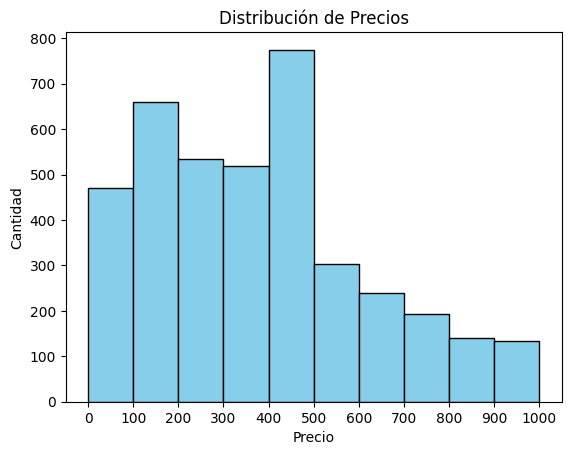

In [37]:
#Distribución de precios histograma

counts, bin_edges, _ = plt.hist(df["price"], bins=10, range=(0,1000),color="skyblue",edgecolor="black")

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)

# Etiquetas y título del gráfico
plt.xlabel("Precio")
plt.ylabel("Cantidad")
plt.title("Distribución de Precios")
plt.show()

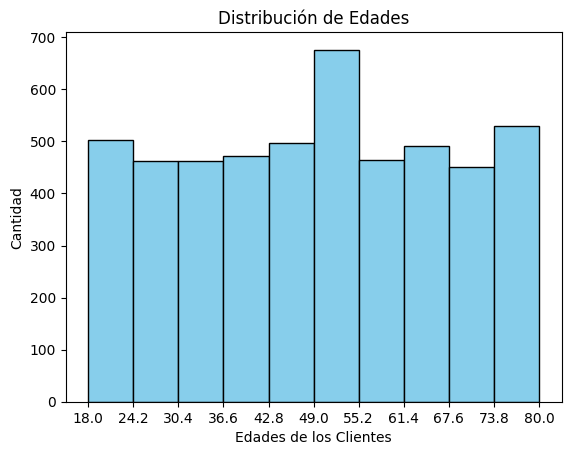

In [38]:
#Distribución de edades de clientes-Histograma 

counts, bin_edges, _ = plt.hist(df["customer_age"], bins=10, color="skyblue", edgecolor="black")

# Mostrar las marcas de los bins en el eje X
plt.xticks(bin_edges)

# Etiquetas y título del gráfico
plt.xlabel("Edades de los Clientes")
plt.ylabel("Cantidad")
plt.title("Distribución de Edades")
plt.show()

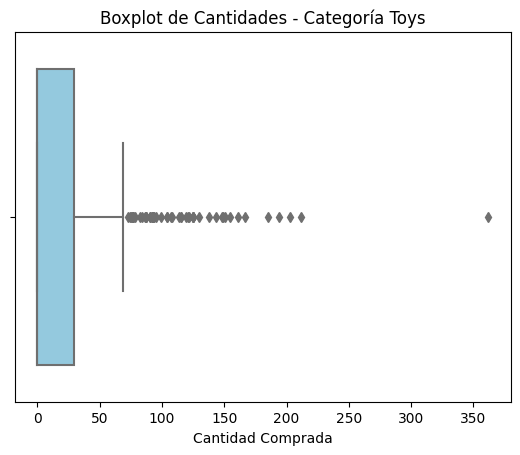

In [41]:
# dispersión de cantidades con Boxplot de la categoria toys 

df_toys = df[df["product_category"] == "Toys"]

# Graficar BoxPlot
sns.boxplot(x=df_toys["quantity"], color='skyblue')

# Etiquetas y título del gráfico
plt.xlabel("Cantidad Comprada")
plt.title("Boxplot de Cantidades - Categoría Toys")

plt.show()

In [42]:
#Gastos para categorías “Fashion” y “Sports”
# Filtrar datos
df_fashion = df[df["product_category"] == "Fashion"]
df_sports = df[df["product_category"] == "Sports"]


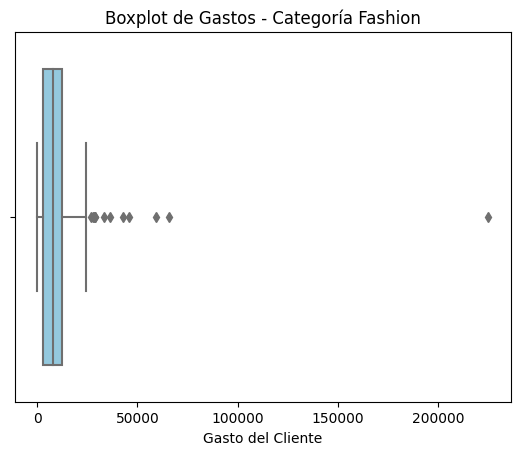

In [43]:
# BoxPlot Categoría Fashion
sns.boxplot(x=df_fashion["order_value"], color = 'skyblue')
plt.xlabel("Gasto del Cliente")
plt.title("Boxplot de Gastos - Categoría Fashion")
plt.show()

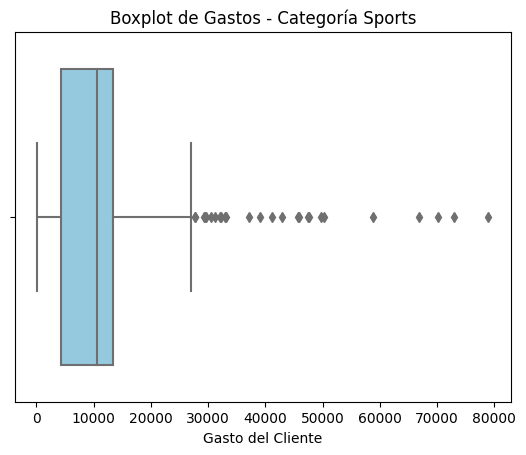

In [44]:
# BoxPlot Categoría Sports
sns.boxplot(x=df_sports["order_value"], color = 'skyblue')
plt.xlabel("Gasto del Cliente")
plt.title("Boxplot de Gastos - Categoría Sports")
plt.show()

In [45]:
#Identificar outliers en order_value con IQR
# calcular Q1, Q3 e IQR
Q1 = df["order_value"].quantile(0.25)
Q3 = df["order_value"].quantile(0.75)
IQR = Q3-Q1

In [46]:
# calcular límite inferior y superior
limite_inferior = Q1-1.5*IQR
limite_superior = Q3+1.5*IQR

In [47]:
# Mostrar resultados
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)

Primer cuartil:  3096.25
Tercer cuartil:  13159.25
IQR:  10063.0


In [48]:
print("\nRegistros abajo del límite inferior")
print(df[df["order_value"]<limite_inferior])


Registros abajo del límite inferior
Empty DataFrame
Columns: [order_id, order_date, customer_id, product_category, price, quantity, order_value, payment_method, city, state, customer_age]
Index: []


In [49]:
print("\nRegistros arriba del límite superior")
print(df[df["order_value"]>limite_superior])


Registros arriba del límite superior
      order_id  order_date  customer_id product_category  price  quantity  \
8            9  2024-03-14         2925           Beauty     55         1   
123        124  2024-06-21         1389      Electronics   1947         0   
155        156  2024-08-30         2901          Grocery     36         1   
199        200  2024-12-18         2919          Fashion   5174         0   
265        266  2024-07-31         1905      Electronics   2897         0   
...        ...         ...          ...              ...    ...       ...   
4934      4935  2024-05-19         1502      Electronics   4282         0   
4936      4937  2024-12-17         1907             Home   1522         0   
4942      4943  2024-11-02         1979      Electronics   6478         0   
4947      4948  2024-07-09         1447           Beauty     45         1   
4952      4953  2024-10-13         2993           Sports   2679         0   

      order_value payment_method     

In [50]:
#Identificar outliers en order_value usando Z-Score

#cálculo de la media
mean = df['order_value'].mean()

#cálculo de la desviación estándar
std = df['order_value'].std()

#Crea el z score
df['z'] = (df['order_value']-mean)/std

#Calcula los valores extremos
print(df[df['z']>3])

      order_id  order_date  customer_id product_category  price  quantity  \
293        294  2024-05-01         2149      Electronics   3336         0   
369        370  2024-10-09         2784      Electronics   5973         0   
375        376  2024-02-04         2285      Electronics   4782         0   
391        392  2024-03-06         2981      Electronics   2463         0   
397        398  2024-03-12         2024      Electronics   4893         0   
...        ...         ...          ...              ...    ...       ...   
4698      4699  2024-04-20         2059      Electronics   5227         0   
4732      4733  2024-10-06         2685           Sports   3394         0   
4908      4909  2024-10-19         1119      Electronics   3927         0   
4921      4922  2024-11-15         1621           Sports   2765         0   
4942      4943  2024-11-02         1979      Electronics   6478         0   

      order_value payment_method      city state  customer_age         z  


In [51]:
#segmentar los clientes por edad y por volumen de compra

def classify_volume(row):
    age = row['customer_age']
    qty = row['quantity']

    # 1. Manejo de valores nulos/faltantes
    # pd.isna() verifica de forma robusta si el valor es NaN
    if pd.isna(age) or pd.isna(qty):
        return "Error en Datos"

    # --- 2. Segmentación de Altas Cantidades ---
    if qty > 22:
        if age > 55:
            return "Sr. High Volume"
        else: # age <= 55
            return "Jr. High Volume"
            
    # --- 3. Segmentación Bajas Cantidades ---
    elif qty <= 22:
        if age > 55:
            return "Sr. Low Volume"
        else: # age < 55
            return "Jr. Low Volume"

# aplicar función y verificar cambios
df["volume_segment"] = df.apply(classify_volume, axis = 1)
print(df['volume_segment'].value_counts())

Jr. Low Volume     2880
Sr. High Volume    1199
Sr. Low Volume      736
Error en Datos      150
Jr. High Volume      43
Name: volume_segment, dtype: int64
